In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st
from IPython.display import display

DATA_ROOT = 'C:/Users/oles/Documents/Data/antje_ca1/data_sig'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


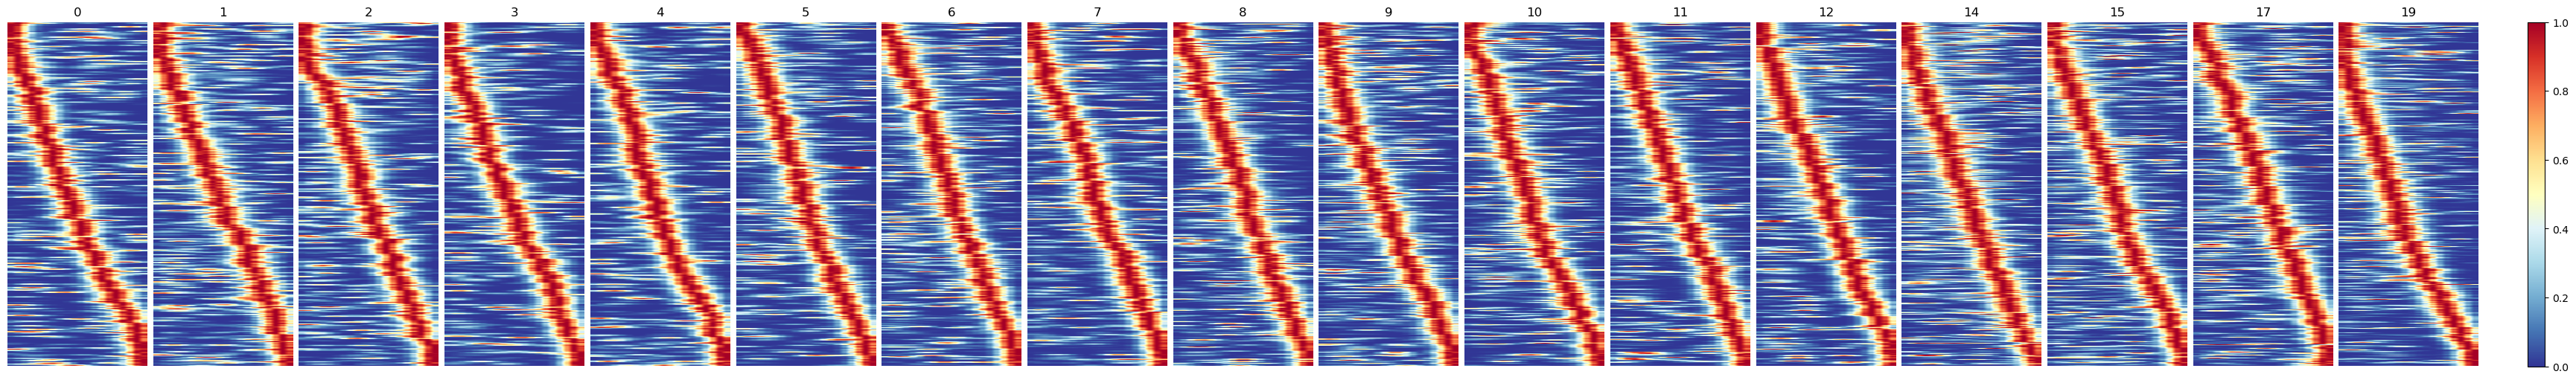

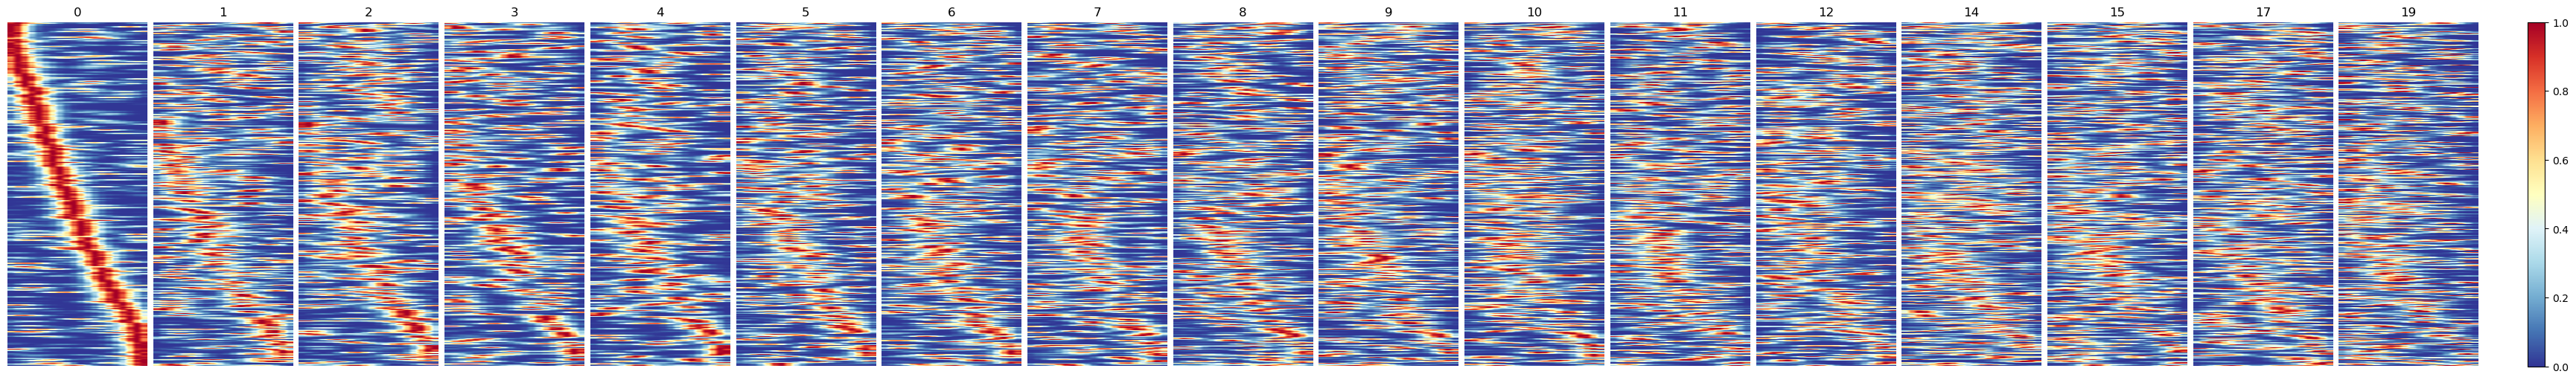

In [2]:
datapath = r'D:/Antje_CA1/data_sig/170.h5'
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
hist_sorts = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='0', maps = maps, reference_type='own_reference', transients = False, hist='hist',  standardize='stand')
plots.plot_arrays(hist_sorts, ['0']+maps, remove_zero_rows=True)

hist_sorts = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='0', maps = maps, reference_type='reference', transients = False, hist='hist',  standardize='stand')
plots.plot_arrays(hist_sorts, ['0']+maps,remove_zero_rows=True)

In [ ]:
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]
results = []

for datapath in datapaths:
    scores_test, scores_new_list, predictions_test, predictions_new_list, y_test, y_new_list = analysis.decode_position(
        datapath, '0', maps, 'Context1', model='gnb', use_circular=False, align_sessions=False)
    
    results.append({
        'datapath': datapath,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'predictions_test': predictions_test,
        'predictions_new_list': predictions_new_list,
        'y_test': y_test,
        'y_new_list': y_new_list
    })

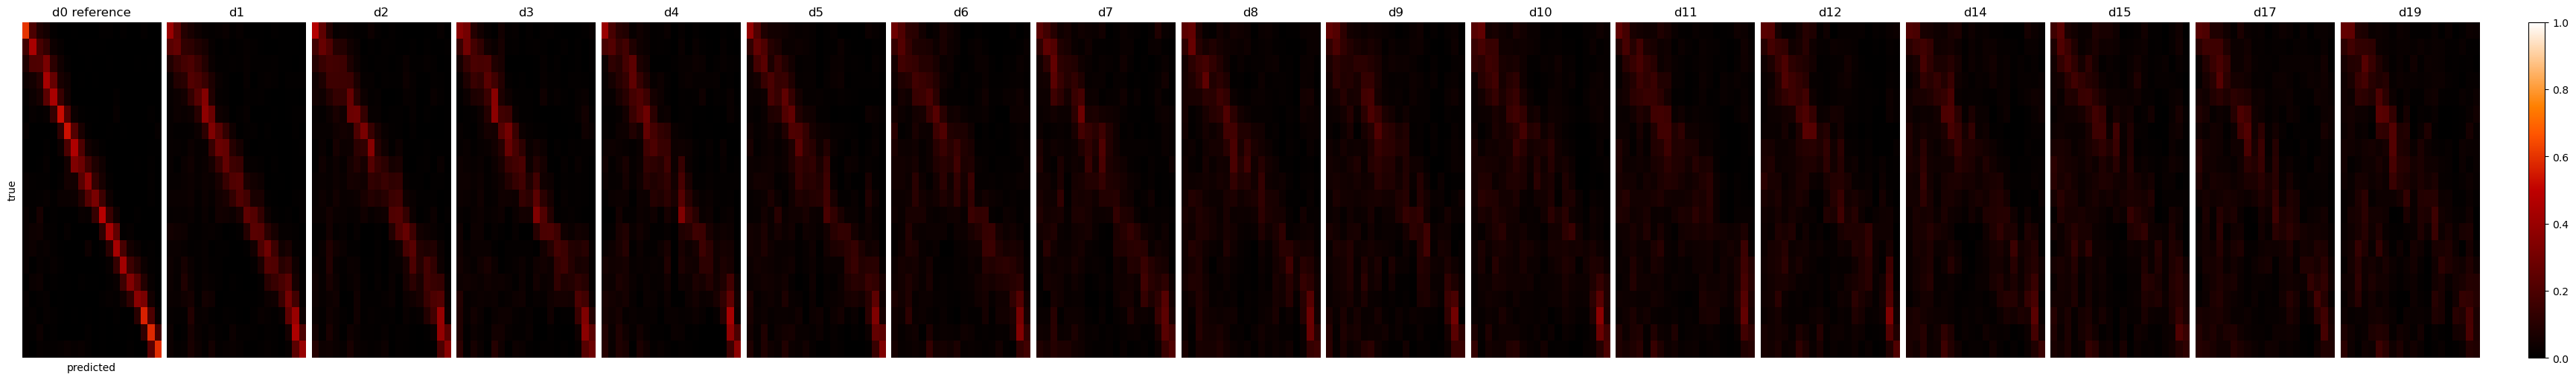

In [4]:
num_days = len(results[0]['scores_new_list'])
matrix_shape = results[0]['scores_new_list'][0]['cm_prob'].shape
sum_matrices = [np.zeros(matrix_shape) for _ in range(num_days)]
days = ['d0 reference', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10', 'd11', 'd12', 'd14', 'd15', 'd17', 'd19']
for a in range(len(results)):
    for day in range(num_days):
        sum_matrices[day] += results[a]['scores_new_list'][day]['cm_prob']

num_a = len(results)
avg_matrices = [sum_matrix / num_a for sum_matrix in sum_matrices]

avg_matrice_ref = np.mean([results[a]['scores_test']['cm_prob'] for a in range(len(results)) ],axis=0)
avg_matrices.insert(0, avg_matrice_ref)
plots.plot_arrays(avg_matrices, days, aspect=0.0, xlabel='predicted', ylabel='true', show_colorbar=True, smooth_sigma=False, remove_zero_rows=False, cmap='gist_heat', global_scale=True, scale_per_neuron=False)

In [5]:
results_shuff = []

for datapath in datapaths:
    scores_test, scores_new_list, predictions_test, predictions_new_list, y_test, y_new_list = analysis.decode_position(
        datapath, '0', maps, 'Context1', model='gnb', use_circular=False, align_sessions=False, shuffle=True)
    
    results_shuff.append({
        'datapath': datapath,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'predictions_test': predictions_test,
        'predictions_new_list': predictions_new_list,
        'y_test': y_test,
        'y_new_list': y_new_list
    })

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,52.372200,16,80,3.273262,29.866128,4.010545e-27,1.334263e-07,0.285789,0.227460
1,condition,307.188704,1,5,307.188704,24.705229,4.210185e-03,4.210185e-03,0.701230,1.000000
2,time * condition,48.606140,16,80,3.037884,18.312849,2.189110e-20,5.937006e-05,0.270803,0.170656


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,-15.0541,2.3427e-05,0.0004,***,-6.1458,Cohen's d,1.4561,6.4110,-4.9549,0.8062,6,True,0.7650
1,T2,C1,C2,t-test,-8.5955,0.0004,0.0060,**,-3.5091,Cohen's d,2.7171,6.7079,-3.9908,1.1373,6,True,0.4977
2,T3,C1,C2,t-test,-6.2657,0.0015,0.0258,*,-2.5580,Cohen's d,3.1107,6.7823,-3.6716,1.4353,6,True,0.0615
3,T4,C1,C2,t-test,-5.2830,0.0032,0.0550,,-2.1568,Cohen's d,3.3496,6.6262,-3.2766,1.5192,6,True,0.7123
4,T5,C1,C2,t-test,-3.4786,0.0177,0.3007,,-1.4201,Cohen's d,3.7432,6.5677,-2.8245,1.9889,6,True,0.9913
5,T6,C1,C2,t-test,-4.2045,0.0085,0.1437,,-1.7165,Cohen's d,3.8690,6.5767,-2.7077,1.5774,6,True,0.9147
6,T7,C1,C2,t-test,-4.1683,0.0088,0.1488,,-1.7017,Cohen's d,4.2605,6.6784,-2.4179,1.4209,6,True,0.8483
7,T8,C1,C2,t-test,-3.5325,0.0167,0.2838,,-1.4421,Cohen's d,4.4119,6.6630,-2.2511,1.5610,6,True,0.6146
8,T9,C1,C2,t-test,-4.4205,0.0069,0.1171,,-1.8047,Cohen's d,4.6098,6.8163,-2.2064,1.2226,6,True,0.9381
9,T10,C1,C2,t-test,-3.7274,0.0136,0.2313,,-1.5217,Cohen's d,4.8457,6.6365,-1.7908,1.1769,6,True,0.0986


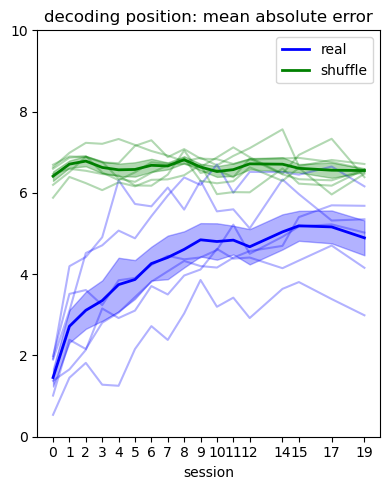

In [6]:

mae_array = np.array([[results[a]['scores_new_list'][day]['mae'] for a in range(len(results))] 
                      for day in range(len(results[0]['scores_new_list']))])
mae_ref= np.array([results[a]['scores_test']['mae'] for a in range(len(results))])
mae_array = np.vstack([mae_ref, mae_array])

mae_array_shuff = np.array([[results_shuff[a]['scores_new_list'][day]['mae'] for a in range(len(results_shuff))]
                            for day in range(len(results_shuff[0]['scores_new_list']))])
mae_ref_shuff= np.array([results_shuff[a]['scores_test']['mae'] for a in range(len(results_shuff))])
mae_array_shuff = np.vstack([mae_ref_shuff, mae_array_shuff])

fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plots.plot_average_geometry([mae_array.T, mae_array_shuff.T], ['0']+maps, colors=['b', 'g'], title='decoding position: mean absolute error', ax=ax, ylim=[0, 10],  labels= ['real', 'shuffle'])
stat1 = st.repeated_measures_anova_general([mae_array.T, mae_array_shuff.T])
display(stat1[0])
display(stat1[1])




In [ ]:
all_before_correlations = []
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
for datapath in datapaths:

    
    hist_sorts = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='0', maps = maps, transients = False, hist='hist')
    manifold_reference = hist_sorts[0] 
    manifold_before_rotation = [hist_sorts[day] for day in range(1,len(hist_sorts))]
    before_correlation = [pop.ManifoldAnalysis.population_correlation(manifold_before_rotation[day], manifold_reference) for day in range(len(manifold_before_rotation))]    
    
    w1,w2 =analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=['0'])
    within_session_correlation = pop.ManifoldAnalysis.population_correlation(w1[0], w2[0])
    
    before_correlation= [within_session_correlation] + before_correlation
    all_before_correlations.append(before_correlation)



all_before_correlations = np.vstack(all_before_correlations)

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.976429,16,0.123527,60.322068,8.300126e-38,0.769105,0.144635
1,Error,0.163823,80,0.002048,NaN,NaN,NaN,NaN


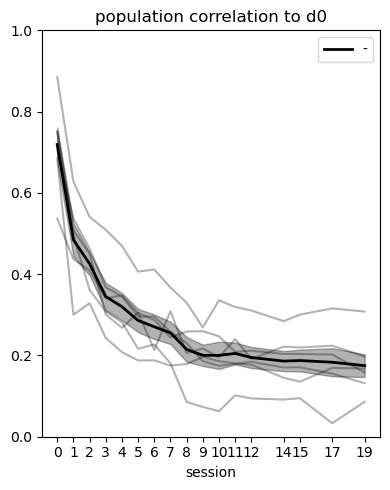

In [7]:

fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([all_before_correlations], ['0']+maps, colors=['k'], ax=ax, title='population correlation to d0', ylim=[0, 1], labels=['-'])
st.repeated_measures_anova_single_condition(all_before_correlations)# included day 0 as